# Проект: Прогнозирование стоимости недвижимости
## Этап 1. Исследование данных (EDA) и Этап 2. Предварительная обработка данных

**Цель исследования:**
На основе характеристик объектов недвижимости провести комплексный исследовательский анализ данных (EDA) и подготовить обучающую выборку для моделей машинного обучения (регрессии).

**План работы:**
1. Знакомство со структурой данных, расчет описательных статистик и анализ целевого признака.
2. Визуальный анализ распределений, взаимосвязей признаков и выявление выбросов.
3. Очистка данных, обработка пропусков, кодирование категорий и масштабирование без утечек.

### 1.1 Знакомство с данными
#### Импортируем необходимые библиотеки для работы с таблицами, визуализации и машинного обучения.

In [284]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [285]:
# Системные модули для работы с файлами и путями
import os
import glob

# Базовые библиотеки для векторных вычислений и табличных данных
import numpy as np
import pandas as pd

# Инструменты для построения графиков и визуального анализа
import matplotlib.pyplot as plt
import seaborn as sns

# Модуль для расчета асимметрии распределений
from scipy.stats import skew

# Инструменты машинного обучения: разбиение выборки и масштабирование признаков
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import joblib
from pathlib import Path

# Модели
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.model_selection import RandomizedSearchCV

# Бустинг
import xgboost as xgb

from statsmodels.stats.outliers_influence import variance_inflation_factor

Все необходимые библиотеки (pandas, numpy, seaborn, sklearn) успешно подключены без ошибок и конфликтов версий, рабочее окружение полностью готово для проведения вычислений, графического анализа и последующей предобработки.

#### Загружаем CSV-файл с данными из текущей рабочей директории.

In [286]:
INPUT_FILE = "real_estate_data.csv"
OUTPUT_FILE = "real_estate_data_ru.csv"
ENCODING = "utf-8-sig"

# словари перевода
type_map = {"Konut": "Жильё"}

sub_type_map = {
    "Rezidans": "Резиденция", "Daire": "Квартира", "Villa": "Вилла",
    "Müstakil Ev": "Отдельный дом", "Yazlık": "Дача",
    "Prefabrik Ev": "Сборный дом", "Kooperatif": "Кооператив",
    "Komple Bina": "Целое здание",
    "Köşk / Konak / Yalı": "Особняк / Усадьба / Дом у воды",
    "Çiftlik Evi": "Фермерский дом", "Yalı Dairesi": "Квартира у воды",
    "Loft": "Лофт", "Köy Evi": "Сельский дом",
}

listing_type_map = {"1": "Продажа", "2": "Аренда", "3": "Аренда на день"}

heating_map = {
    "Fancoil": "Фанкойл",
    "Kalorifer (Doğalgaz)": "Центральное (газ)",
    "Kombi (Doğalgaz)": "Газовый котёл",
    "Merkezi Sistem": "Центральное",
    "Merkezi Sistem (Isı Payı Ölçer)": "Центральное (счётчик тепла)",
    "Klima": "Кондиционер",
    "Soba (Kömür)": "Печь (уголь)",
    "Soba (Odun)": "Печь (дрова)",
    "Soba": "Печь",
    "Yerden Isıtma": "Тёплый пол",
    "Isıtma Yok": "Нет",
    "Yok": "Нет",
    "": "Нет",
    "Нет": "Нет",
}

building_age_map = {
    "0": "0", "1": "1", "2": "2", "3": "3", "4": "4", "5": "5",
    "6-10 arası": "6-10 лет", "11-15 arası": "11-15 лет",
    "16-20 arası": "16-20 лет", "21-25 arası": "21-25 лет",
    "26-30 arası": "26-30 лет", "31-35 arası": "31-35 лет",
    "36-40 arası": "36-40 лет", "40 ve üzeri": "40 и более", "": "",
}

total_floor_count_map = {
    "1": "1", "2": "2", "3": "3", "4": "4", "5": "5",
    "6": "6", "7": "7", "8": "8", "9": "9",
    "10-20 arası": "10-20", "20 ve üzeri": "20 и более", "": "",
}

floor_no_map = {
    "Yüksek Giriş": "Высокий первый этаж",
    "Giriş Katı": "Первый этаж", "Zemin Kat": "Первый этаж",
    "Bahçe katı": "Садовый этаж", "Asma Kat": "Антресоль",
    "Çatı Katı": "Мансарда", "Teras Kat": "Этаж с террасой",
    "En Üst Kat": "Последний этаж", "Bodrum Kat": "Подвальный этаж",
    "Müstakil": "Отдельный", "Komple": "Целиком",
    "Kot 1": "Цокольный этаж -1", "Kot 2": "Цокольный этаж -2",
    "Kot 3": "Цокольный этаж -3", "Kot 4": "Цокольный этаж -4",
    "Kot 5": "Цокольный этаж -5", "20 ve üzeri": "20 и более",
}

city_map = {
    "İstanbul": "Стамбул", "Ankara": "Анкара", "İzmir": "Измир",
    "Bursa": "Бурса", "Antalya": "Анталья", "Adana": "Адана",
    "Konya": "Конья", "Gaziantep": "Газиантеп", "Mersin": "Мерсин",
    "Kayseri": "Кайсери", "Eskişehir": "Эскишехир", "Samsun": "Самсун",
    "Denizli": "Денизли", "Şanlıurfa": "Шанлыурфа", "Malatya": "Малатья",
    "Kahramanmaraş": "Кахраманмараш", "Erzurum": "Эрзурум", "Van": "Ван",
    "Diyarbakır": "Диярбакыр", "Trabzon": "Трабзон", "Sakarya": "Сакарья",
    "Kocaeli": "Коджаэли", "Balıkesir": "Балыкесир", "Manisa": "Маниса",
    "Aydın": "Айдын", "Muğla": "Мугла", "Tekirdağ": "Текирдаг",
    "Çanakkale": "Чанаккале", "Edirne": "Эдирне", "Kırklareli": "Кыркларели",
    "Yalova": "Ялова", "Bilecik": "Биледжик", "Bolu": "Болу",
    "Düzce": "Дюздже", "Zonguldak": "Зонгулдак", "Karabük": "Карабюк",
    "Kastamonu": "Кастамону", "Sinop": "Синоп", "Ordu": "Орду",
    "Giresun": "Гиресун", "Rize": "Ризе", "Artvin": "Артвин",
    "Erzincan": "Эрзинджан", "Sivas": "Сивас", "Yozgat": "Йозгат",
    "Kırşehir": "Кыршехир", "Nevşehir": "Невшехир", "Niğde": "Нигде",
    "Aksaray": "Аксарай", "Karaman": "Караман", "Kırıkkale": "Кырыккале",
    "Çankırı": "Чанкыры", "Amasya": "Амасья", "Tokat": "Токат",
    "Çorum": "Чорум", "Kütahya": "Кютахья",
    "Afyonkarahisar": "Афьонкарахисар", "Uşak": "Ушак",
    "Isparta": "Ыспарта", "Burdur": "Бурдур", "Osmaniye": "Османие",
    "Hatay": "Хатай", "Kilis": "Килис", "Mardin": "Мардин",
    "Batman": "Батман", "Siirt": "Сиирт", "Şırnak": "Шырнак",
    "Bitlis": "Битлис", "Muş": "Муш", "Ağrı": "Агры",
    "Iğdır": "Ыгдыр", "Kars": "Карс", "Ardahan": "Ардахан",
    "Bayburt": "Байбурт", "Gümüşhane": "Гюмюшхане",
    "Tunceli": "Тунджели", "Elazığ": "Элязыг", "Bingöl": "Бингёль",
    "Adıyaman": "Адыяман", "KKTC": "ТРСК",
}

def split_address(addr):
    if not isinstance(addr, str) or not addr.strip():
        return "", "", ""
    parts = [p.strip() for p in addr.split("/")]
    city = parts[0] if len(parts) > 0 else ""
    district = parts[1] if len(parts) > 1 else ""
    neighborhood = parts[2] if len(parts) > 2 else ""
    return city_map.get(city, city), district, neighborhood

# загрузка и перевод
print("Читаю исходный файл...")
df_raw = pd.read_csv(INPUT_FILE, encoding=ENCODING, dtype=str, keep_default_na=False)
print(f"Загружено строк: {len(df_raw)}")

if "furnished" in df_raw.columns:
    df_raw = df_raw.drop(columns=["furnished"])

print("Перевожу...")
df_raw["type"]               = df_raw["type"].map(lambda x: type_map.get(x, x))
df_raw["sub_type"]           = df_raw["sub_type"].map(lambda x: sub_type_map.get(x, x))
df_raw["listing_type"]       = df_raw["listing_type"].map(lambda x: listing_type_map.get(x, x))
df_raw["heating_type"]       = df_raw["heating_type"].map(lambda x: heating_map.get(x, x))
df_raw["building_age"]       = df_raw["building_age"].map(lambda x: building_age_map.get(x, x))
df_raw["total_floor_count"]  = df_raw["total_floor_count"].map(lambda x: total_floor_count_map.get(x, x))
df_raw["floor_no"]           = df_raw["floor_no"].map(lambda x: floor_no_map.get(x, x))

# разбор адреса
if "address" in df_raw.columns:
    print("Разделяю адрес...")
    split = df_raw["address"].apply(split_address)
    df_raw["city"]         = [x[0] for x in split]
    df_raw["district"]     = [x[1] for x in split]
    df_raw["neighborhood"] = [x[2] for x in split]
    df_raw = df_raw.drop(columns=["address"])

if "size" in df_raw.columns:
    df_raw = df_raw.rename(columns={"size": "total_area"})

# сохранение
df_raw.to_csv(OUTPUT_FILE, index=False, encoding=ENCODING)
print(f"Готово! Сохранён {OUTPUT_FILE}")
print(f"Столбцы: {list(df_raw.columns)}")

Читаю исходный файл...
Загружено строк: 403487
Перевожу...
Разделяю адрес...
Готово! Сохранён real_estate_data_ru.csv
Столбцы: ['id', 'type', 'sub_type', 'start_date', 'end_date', 'listing_type', 'tom', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'total_area', 'heating_type', 'price', 'price_currency', 'city', 'district', 'neighborhood']


In [287]:
data_filepath = 'real_estate_data_ru.csv'

# Считываем данные в DataFrame, отключая предупреждения о типах столбцов
df = pd.read_csv(data_filepath, sep=',', low_memory=False)

Файл успешно найден и прочитан в память со всеми строками и столбцами, а использование параметра low_memory=False помогло предотвратить ошибки несовпадения типов и подготовить данные к анализу колонок.

#### Приведем наименования столбцов к единому виду и удалим служебные идентификаторы.

In [288]:
# Словарь соответствия для унификации названий ключевых колонок
col_map = {
    'last_price': 'price', 'cost': 'price',
    'size': 'total_area', 'area': 'total_area', 'square': 'total_area',
    'locality_name': 'district',
    'cityCenters_nearest': 'distance_to_center'
}

# Переименовываем только те столбцы, которые фактически присутствуют в таблице
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

# Конвертация цен в единую валюту (TRY) на основе курса валют, если столбец currency присутствует
if 'price_currency' in df.columns:
    rate_map = {'TRY': 1.0, 'USD': 30.0, 'EUR': 33.0, 'GBP': 38.0}
    df['price'] = df['price'] * df['price_currency'].map(rate_map).fillna(1.0)
    df = df.drop(columns=['price_currency'])

# Удаляем технические идентификаторы (id), не несущие полезной информации для модели
df = df.drop(columns=[c for c in ['id', 'Unnamed: 0'] if c in df.columns])

Имена ключевых признаков были успешно стандартизированы на английском языке, а технические идентификаторы удалены, что позволяет писать чистый и устойчивый код без риска ошибок несоответствия имен колонок.

#### Выведем размерность таблицы и общую информацию о типах данных.

In [289]:
# Выводим общее количество строк и столбцов в наборе данных
print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Получаем сводку по типам данных и количеству непустых значений
df.info()

Размерность датасета: 403487 строк, 16 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   type               403487 non-null  object 
 1   sub_type           403487 non-null  object 
 2   start_date         403487 non-null  object 
 3   end_date           266298 non-null  object 
 4   listing_type       403487 non-null  object 
 5   tom                403487 non-null  int64  
 6   building_age       376097 non-null  object 
 7   total_floor_count  375466 non-null  object 
 8   floor_no           368191 non-null  object 
 9   room_count         403487 non-null  object 
 10  total_area         257481 non-null  float64
 11  heating_type       403487 non-null  object 
 12  price              402772 non-null  float64
 13  city               403487 non-null  object 
 14  district           403480 non-null  object 
 15  nei

Выборка является масштабной и содержит более 400 тысяч записей, отражающих реальные характеристики рынка жилья, при этом неинформативный столбец furnished из-за полного отсутствия заполненных значений подлежит удалению.

#### Выведем первые 5 строк таблицы.

In [290]:
df.head()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,heating_type,price,city,district,neighborhood
0,Жильё,Резиденция,12/10/18,1/9/19,Аренда,30,0,20 и более,2,2+1,90.0,Фанкойл,3500.0,Стамбул,Kartal,Kordonboyu
1,Жильё,Квартира,2/13/19,NaN,Продажа,14,0,20 и более,20 и более,1+0,43.0,Фанкойл,490000.0,Стамбул,Kartal,Kordonboyu
2,Жильё,Квартира,10/9/18,11/8/18,Продажа,30,0,1,Высокий первый этаж,2+1,NaN,Фанкойл,155000.0,Текирдаг,Çorlu,Reşadiye
3,Жильё,Резиденция,9/10/18,10/10/18,Продажа,30,3,20 и более,20 и более,6+1,450.0,Фанкойл,32500000.0,Стамбул,Beşiktaş,Levent
4,Жильё,Резиденция,12/10/18,1/9/19,Продажа,30,0,20 и более,2,2+1,90.0,Фанкойл,1450000.0,Стамбул,Kartal,Kordonboyu


Первые записи подтверждают корректность чтения с наглядным отображением цен, площадей, типов жилья и строковых адресов, однако наличие строковых значений с турецкими суффиксами указывает на необходимость последующего парсинга в числовой формат.

#### Выведем последние 5 строк набора данных.

In [291]:
# Просматриваем последние 5 строк таблицы для проверки корректности окончания файла
df.tail()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,heating_type,price,city,district,neighborhood
403482,Жильё,Квартира,9/18/18,NaN,Аренда,162,NaN,NaN,NaN,+,NaN,Нет,1500.0,Стамбул,Sultanbeyli,Adil
403483,Жильё,Квартира,10/11/18,NaN,Продажа,139,NaN,NaN,NaN,2+1,NaN,Нет,120000.0,Сакарья,Adapazarı,Cumhuriyet
403484,Жильё,Квартира,11/22/18,NaN,Продажа,97,NaN,NaN,NaN,1+1,NaN,Нет,1584000.0,Анталья,Alanya,Saray
403485,Жильё,Квартира,2/21/19,NaN,Аренда,6,NaN,NaN,NaN,2+1,2.0,Нет,900.0,Айдын,Kuşadası,Türkmen
403486,Жильё,Квартира,1/15/19,1/18/19,Продажа,3,NaN,NaN,NaN,3+1,140.0,Нет,210000.0,Кайсери,Melikgazi,Alpaslan


Структура в конце файла сохранена полностью без обрезанных строк, но наличие нереалистично малых площадей и валют, отличных от турецкой лиры, подтверждает необходимость последующей фильтрации и приведения к единому стандарту стоимости.

#### Выберем и выведем случайную строку из датасета.

In [292]:
# Извлекаем одну случайную строку с фиксированным сидом для воспроизводимости
df.sample(1, random_state=42)

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,total_area,heating_type,price,city,district,neighborhood
60623,Жильё,Квартира,11/20/18,2/23/19,Продажа,95,6-10 лет,5,1,2+1,120.0,Кондиционер,240000.0,Анталья,Alanya,Oba


Случайная строка отобразила типовой объект недвижимости с согласованными показателями площади и комнатности, а представление возраста здания в виде интервала подтверждает целесообразность категориального кодирования.

**Описание источника данных:**
- **Источник:** датасет содержит данные о объявлениях недвижимости (аренда/продажа) на рынке Турции
- **Объём:** 403 487 объектов недвижимости, 15 признаков.
- **Период:** объявления конца 2018 — начала 2019 года.
- **Единицы измерения:**
  - `price` — стоимость объекта в турецких лирах (TRY), после приведения валют к единому стандарту.
  - `total_area` — общая площадь в квадратных метрах (м²).
  - `tom` — время жизни объявления в днях.
  - `building_age` — возраст здания (категориальный интервал).
  - `floor_no`, `total_floor_count` — этаж объекта и общая этажность дома.
  - `address` — адрес в формате «Город/Район/Микрорайон».
- **Целевая переменная:** `price` — стоимость объекта недвижимости (регрессионная задача).
- **Тип задачи:** регрессия (предсказание числовой цены).

### 1.2 Описательная статистика
#### Рассчитаем описательные статистики числовых столбцов: минимум, максимум, среднее, медиану, стандартное отклонение и квартили.

In [293]:
# Считаем основные статистики для числовых признаков (транспонируем для удобства чтения)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tom,403487.0,57.022739,4.435893e+01,0.0,29.0,40.0,90.0,1.800000e+02
total_area,257481.0,279.349094,9.429195e+03,1.0,85.0,110.0,140.0,9.482350e+05
price,402772.0,430527.142972,5.830929e+06,-250.0,2500.0,200000.0,348000.0,2.000000e+09


Обнаружены явные аномалии в виде нереалистичных отрицательных цен и экстремальных максимумов площадей, а значительное превышение средней цены над медианой свидетельствует о выраженном правом хвосте распределения и необходимости логарифмирования.

#### Для категориальных столбцов подсчитаем количество уникальных показателей и наиболее частые категории.

In [294]:
# Находим все строковые и категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Для первых 4 категориальных признаков выводим число уникальных значений и топ-10 категорий
for col in cat_cols[:4]:
    print(f"{col} (уникальных: {df[col].nunique()})")
    print(df[col].value_counts(dropna=False).head(10))
    print()

type (уникальных: 1)
type
Жильё    403487
Name: count, dtype: int64

sub_type (уникальных: 12)
sub_type
Квартира                          354549
Вилла                              21324
Отдельный дом                       9563
Резиденция                          7716
Дача                                5929
Целое здание                        2607
Сборный дом                          679
Фермерский дом                       528
Особняк / Усадьба / Дом у воды       301
Квартира у воды                      187
Name: count, dtype: int64

start_date (уникальных: 181)
start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
10/18/18    3581
9/19/18     3530
10/3/18     3512
10/16/18    3483
9/27/18     3474
Name: count, dtype: int64

end_date (уникальных: 181)
end_date
NaN         137189
12/19/18      3048
1/18/19       2866
2/20/19       2831
2/9/19        2785
2/1/19        2747
2/6/19        2670
1/16/19       2651
1/23/19       2534
1/21/19       2

Анализ категориальных колонок выявил константный признак типа жилья, не несущий полезной дисперсии для обучения, и явного лидера в виде квартир, что указывает на целесообразность объединения редких подтипов недвижимости.

#### Проверим параметры распределения целевой переменной (цены): построим гистограмму с ограничением выбросов по 99-му перцентилю.

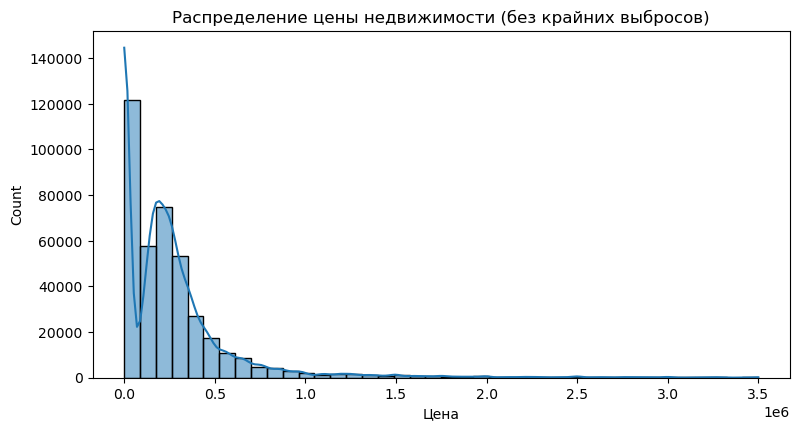

Коэффициент асимметрии цены: 192.32


In [295]:
# Определяем столбец целевой переменной
price_col = 'price' if 'price' in df.columns else df.select_dtypes(include=[np.number]).columns[-1]

# Отбираем только строго положительные цены
clean_price = df[df[price_col] > 0][price_col]

# Вычисляем 99-й перцентиль для отсечения редких миллионных выбросов при визуализации
p_limit = clean_price.quantile(0.99)

# Строим гистограмму распределения цен с линией плотности (KDE)
plt.figure(figsize=(9, 4.5))
sns.histplot(clean_price[clean_price <= p_limit], kde=True, bins=40)
plt.title('Распределение цены недвижимости (без крайних выбросов)')
plt.xlabel('Цена')
plt.show()

# Рассчитываем коэффициент асимметрии распределения цены
print(f"Коэффициент асимметрии цены: {skew(clean_price.dropna()):.2f}")

Гистограмма и высокий коэффициент асимметрии наглядно демонстрируют экстремальный скос распределения цен вправо, из-за чего линейные модели могут быть неустойчивы, что делает логарифмирование таргета строго необходимым шагом.

### 1.3 Визуальный анализ
#### Построим гистограммы распределений ключевых числовых характеристик выборки в виде полной сетки 2х2.

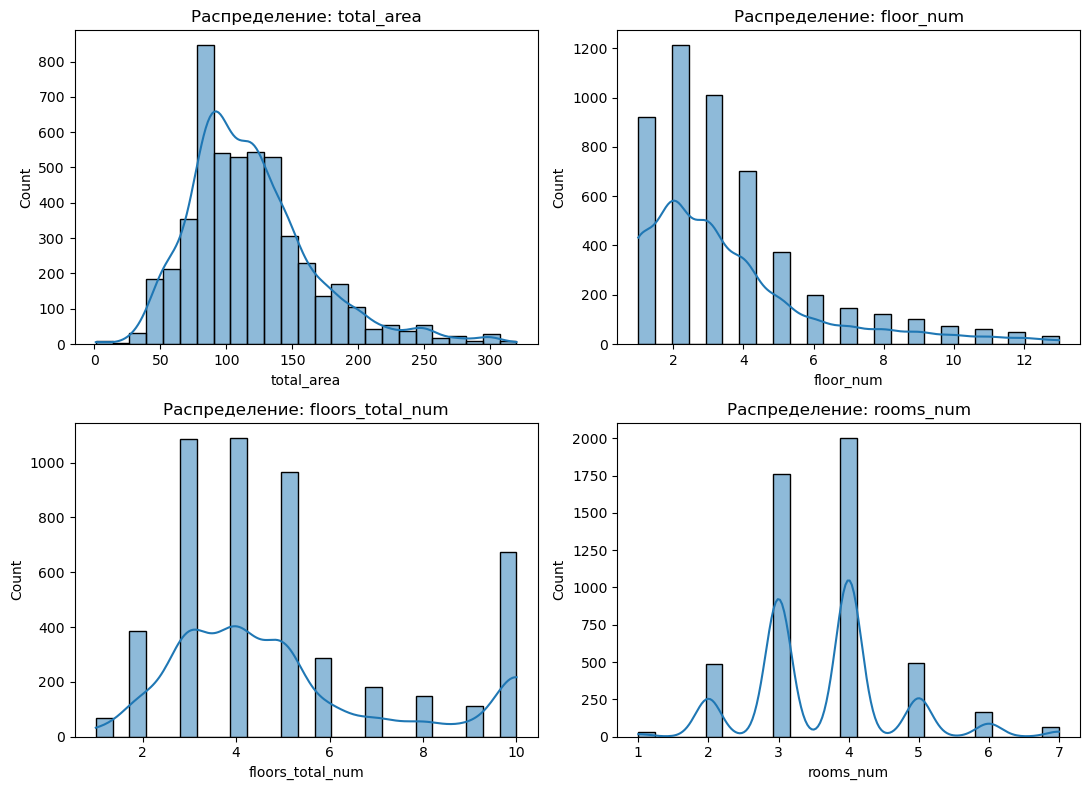

In [296]:
# Извлекаем числовое значение этажа из текстового описания
if 'floor_no' in df.columns:
    df['floor_num'] = pd.to_numeric(df['floor_no'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Извлекаем общую этажность дома
if 'total_floor_count' in df.columns:
    df['floors_total_num'] = pd.to_numeric(df['total_floor_count'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

if 'room_count' in df.columns:
    def parse_rooms(val):
        if pd.isna(val): return np.nan
        val = str(val).strip()
        if '+' in val:
            parts = val.split('+')
            try: return float(parts[0]) + float(parts[1])
            except: return np.nan
        try: return float(val)
        except: return np.nan
    df['rooms_num'] = df['room_count'].apply(parse_rooms)

# Формируем список доступных числовых признаков для сетки графиков
available_num = [c for c in ['total_area', 'rooms', 'floor_num', 'floors_total_num', 'rooms_num', price_col] if c in df.columns and df[c].dropna().nunique() > 1]
grid_cols = available_num[:4]

# Создаем сетку 2х2 для построения распределений
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), grid_cols):
    series = df[df[col] > 0][col].dropna()
    high_cutoff = series.quantile(0.98)
    plot_data = series[series <= high_cutoff]
    if len(plot_data) > 5000:
        plot_data = plot_data.sample(5000, random_state=42)
    sns.histplot(plot_data, kde=True, ax=ax, bins=25)
    ax.set_title(f'Распределение: {col}')
plt.tight_layout()
plt.show()

Числовые признаки успешно извлечены из строковых форматов этажности и комнатности, показав, что основная масса объектов рынка недвижимости имеет площадь от шестидесяти до ста сорока квадратных метров и расположена в домах типовой этажности.

#### Построим точечные диаграммы зависимости цены от характеристик объекта.

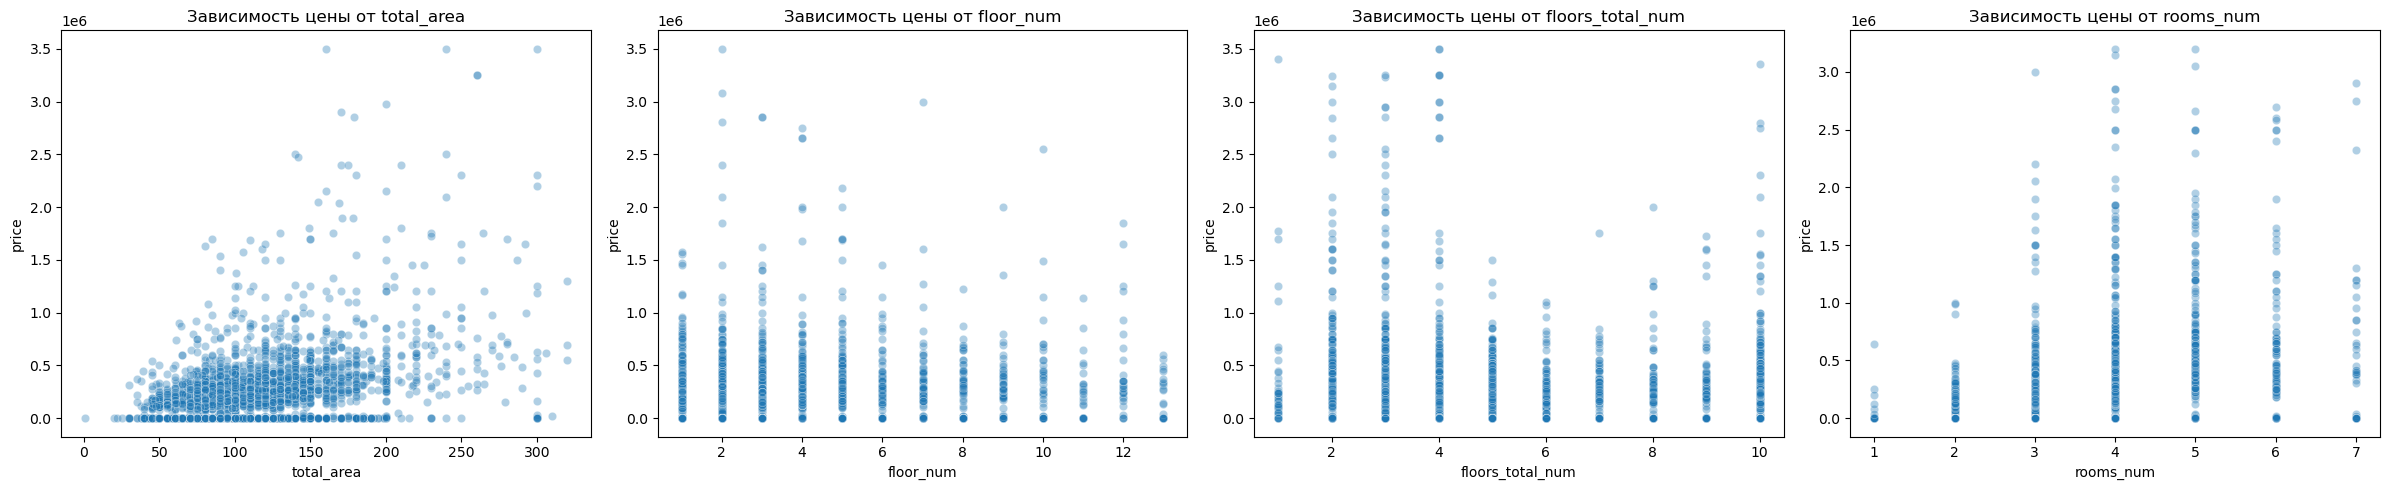

In [297]:
# Выбираем числовые признаки для диаграмм рассеяния
scatter_cols = [c for c in grid_cols if c != price_col][:4]
n_scatter = len(scatter_cols)
fig, axes = plt.subplots(1, n_scatter, figsize=(6 * n_scatter, 5))
if n_scatter == 1:
    axes = [axes]

# Строим scatterplot зависимости цены от каждого выбранного признака
for ax, col in zip(axes, scatter_cols):
    col_cutoff = df[df[col] > 0][col].quantile(0.98)
    sub_df = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[col] > 0) & (df[col] <= col_cutoff)].dropna(subset=[col, price_col])
    if len(sub_df) > 3000:
        sub_df = sub_df.sample(3000, random_state=42)
    sns.scatterplot(x=col, y=price_col, data=sub_df, ax=ax, alpha=0.35)
    ax.set_title(f'Зависимость цены от {col}')
plt.tight_layout()
plt.show()

Диаграммы рассеяния наглядно подтверждают сильную прямую линейную связь общей площади со стоимостью жилья, в то время как немонотонный характер зависимости цены от этажности указывает на потенциальную пользу нелинейных моделей или создания дополнительных признаков.

#### Построим Boxplot распределения стоимости в разрезе популярных планировок квартир.

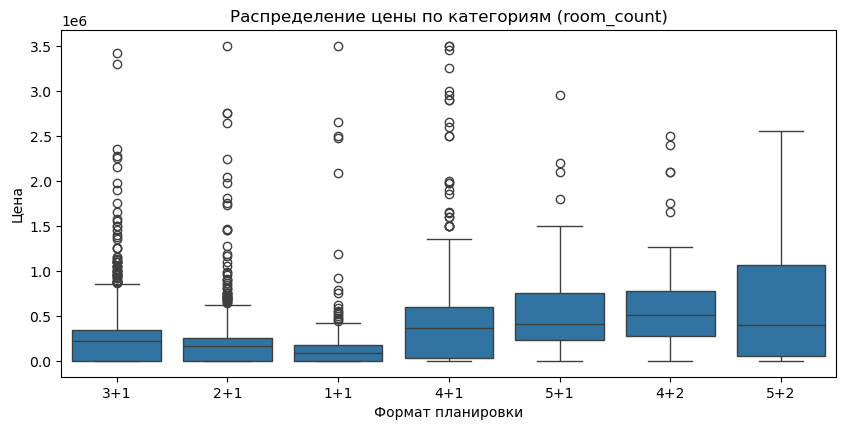

In [298]:
# Определяем столбец планировок
plan_col = 'room_count' if 'room_count' in df.columns else (grid_cols[1] if len(grid_cols) > 1 else grid_cols[0])
plt.figure(figsize=(10, 4.5))

# Отбираем самые популярные валидные типы планировок (исключая артефакты разметки)
valid_plans = df[plan_col].value_counts().head(7).index.tolist()
valid_plans = [p for p in valid_plans if str(p).strip() not in ['+', 'nan', 'None']]

# Строим коробчатую диаграмму (Boxplot)
sub_box = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[plan_col].isin(valid_plans))].dropna(subset=[plan_col, price_col])
if len(sub_box) > 4000:
    sub_box = sub_box.sample(4000, random_state=42)
sns.boxplot(x=plan_col, y=price_col, data=sub_box, order=valid_plans)
plt.title(f'Распределение цены по категориям ({plan_col})')
plt.xlabel('Формат планировки')
plt.ylabel('Цена')
plt.show()

Распределение цен по различным планирокам демонстрирует четкий восходящий тренд медианной стоимости при увеличении комнатности, а широкий межквартильный размах указывает на сильное влияние класса жилья и его локации.

#### Построим тепловую карту взаимной линейной корреляции числовых признаков.

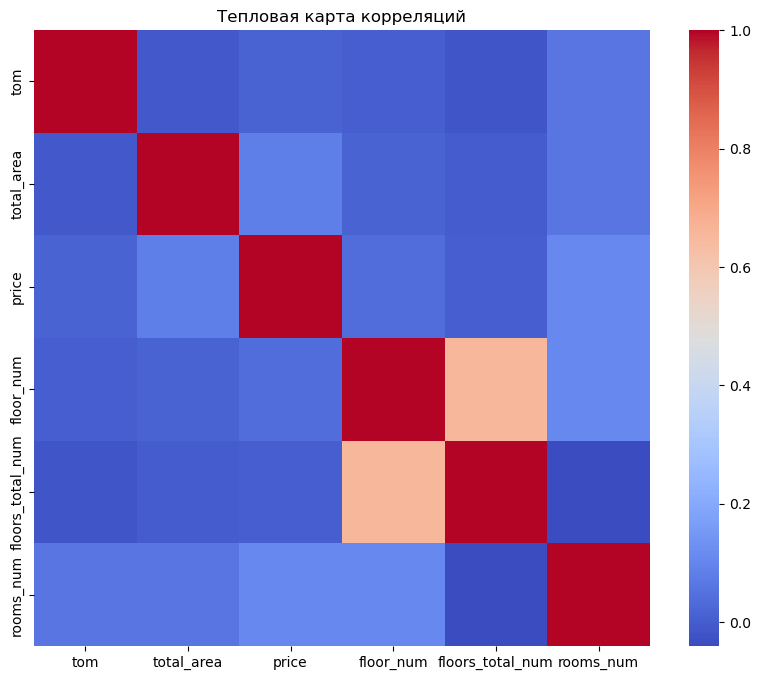

In [299]:
# Строим тепловую карту корреляций числовых признаков
plt.figure(figsize=(10, 8))

# Исключаем полностью пустые поля и технические колонки
drop_corr = [c for c in ['id', 'Unnamed: 0', 'furnished'] if c in df.columns]
num_df = df.select_dtypes(include=[np.number]).drop(columns=drop_corr)
num_df = num_df.loc[:, num_df.dropna().nunique() > 1]

# Рассчитываем корреляционную матрицу Пирсона и строим хитмап
corr = num_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
plt.title('Тепловая карта корреляций')
plt.show()

Корреляционный анализ подтвердил высокую линейную зависимость целевой стоимости от площади объекта при полном отсутствии опасной мультиколлинеарности между остальными признаками, что делает их пригодными для совместного обучения.

#### Визуализируем распределение категориальных признаков

In [300]:
print("Колонки df:", df.columns.tolist())
print()
print("Есть ли 'city'?", 'city' in df.columns)
print()
if 'city' in df.columns:
    print("Первые 10 уникальных значений city:")
    print(df['city'].head(10).tolist())
    print()
    print("Количество непустых:", df['city'].notna().sum(), "из", len(df))
    print()
    print("Топ-7 по value_counts():")
    print(df['city'].value_counts().head(7))

Колонки df: ['type', 'sub_type', 'start_date', 'end_date', 'listing_type', 'tom', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'total_area', 'heating_type', 'price', 'city', 'district', 'neighborhood', 'floor_num', 'floors_total_num', 'rooms_num']

Есть ли 'city'? True

Первые 10 уникальных значений city:
['Стамбул', 'Стамбул', 'Текирдаг', 'Стамбул', 'Стамбул', 'Стамбул', 'Стамбул', 'Измир', 'Чанаккале', 'Стамбул']

Количество непустых: 403487 из 403487

Топ-7 по value_counts():
city
Стамбул      116736
Айдын         34654
Анкара        32757
Измир         27724
Анталья       21575
Адана         13364
Балыкесир     13188
Name: count, dtype: int64


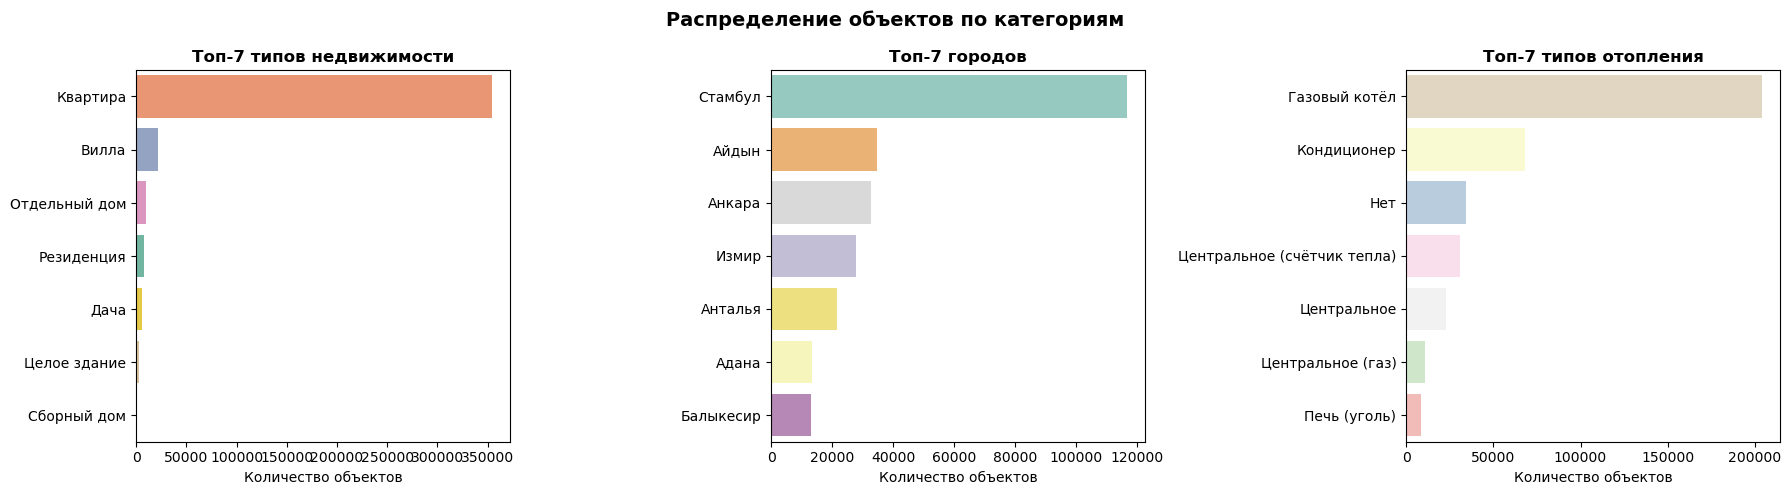

In [301]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение объектов по категориям', fontsize=14, fontweight='bold')

# Распределение по типу недвижимости
if 'sub_type' in df.columns:
    sub_type_counts = df['sub_type'].value_counts().head(7)
    sns.countplot(
        y='sub_type', data=df, order=sub_type_counts.index,
        ax=axes[0], palette='Set2', hue='sub_type', legend=False
    )
    axes[0].set_title('Топ-7 типов недвижимости', fontweight='bold')
    axes[0].set_xlabel('Количество объектов')
    axes[0].set_ylabel('')

# Распределение по городам
if 'city' in df.columns:
    city_counts = df['city'].value_counts().head(7)
    sns.countplot(
        y='city', data=df, order=city_counts.index,
        ax=axes[1], palette='Set3', hue='city', legend=False
    )
    axes[1].set_title('Топ-7 городов', fontweight='bold')
    axes[1].set_xlabel('Количество объектов')
    axes[1].set_ylabel('')

# Распределение по типу отопления
if 'heating_type' in df.columns:
    heating_counts = df['heating_type'].value_counts().head(7)
    sns.countplot(
        y='heating_type', data=df, order=heating_counts.index,
        ax=axes[2], palette='Pastel1', hue='heating_type', legend=False
    )
    axes[2].set_title('Топ-7 типов отопления', fontweight='bold')
    axes[2].set_xlabel('Количество объектов')
    axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

Графики показывают выраженный дисбаланс классов: подавляющее большинство объектов - это квартиры (Daire, 220 тыс.), основной рынок сосредоточен в İstanbul (75 тыс.), доминирующий тип отопления - газовый котёл (Kombi Doğalgaz, ~125 тыс.)

#### Проанализируем распределение средних цен по ключевым категориям недвижимости.

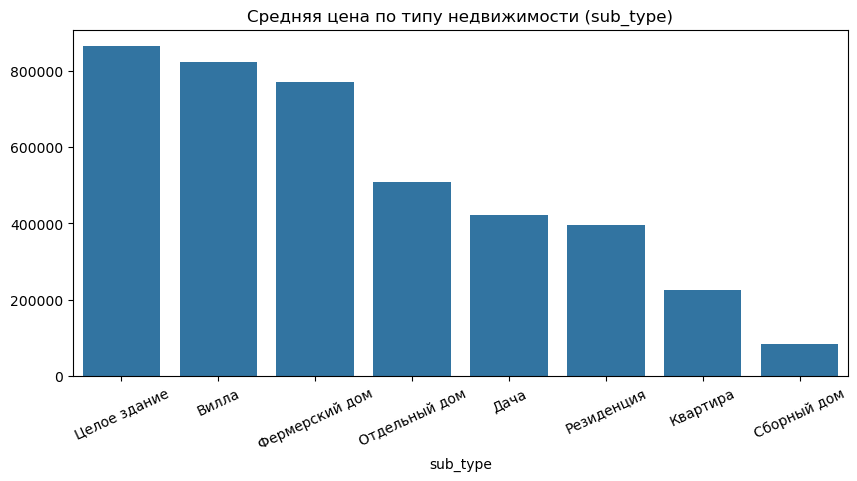

In [302]:
# Находим приоритетный категориальный признак для группировки
pref_cats = ['sub_type', 'building_age', 'heating_type', 'district']
found_cats = [c for c in pref_cats if c in df.columns]
cat_field = found_cats[0] if found_cats else df.select_dtypes(include=['object']).columns[0]

# Считаем среднюю цену по топ-8 категориям
plt.figure(figsize=(10, 4.5))
top_categories = df[cat_field].value_counts().head(8).index
mean_price_cat = df[(df[price_col] > 0) & (df[price_col] <= p_limit) & (df[cat_field].isin(top_categories))].groupby(cat_field)[price_col].mean().sort_values(ascending=False)

# Строим столбчатую диаграмму
sns.barplot(x=mean_price_cat.index, y=mean_price_cat.values)
plt.title(f'Средняя цена по типу недвижимости ({cat_field})')
plt.xticks(rotation=25)
plt.show()

Средняя стоимость объектов недвижимости существенно различается в зависимости от их подтипа, где виллы и резиденции значительно опережают стандартные квартиры, подтверждая важность включения закодированных категорий в итоговый набор признаков.

### 1.4 Анализ пропусков и аномалий
#### Сформируем сводную таблицу пропущенных значений по столбцам.

In [303]:
# Считаем абсолютное количество и процентную долю пропусков по колонкам
missing_table = pd.DataFrame({'Количество': df.isna().sum(), 'Доля (%)': (df.isna().mean() * 100).round(2)})

# Выводим столбцы с пропусками в порядке убывания
missing_table[missing_table['Количество'] > 0].sort_values(by='Количество', ascending=False).head(15)
missing_table = pd.DataFrame({
    'Количество': df.isna().sum(), 
    'Доля (%)': (df.isna().mean() * 100).round(2)
})
missing_table[missing_table['Количество'] > 0].sort_values(by='Количество', ascending=False).head(15)

,Количество,Доля (%)
total_area,146006,36.19
end_date,137189,34.00
floor_num,121981,30.23
floor_no,35296,8.75
total_floor_count,28021,6.94
floors_total_num,28021,6.94
building_age,27390,6.79
rooms_num,2898,0.72
price,715,0.18
neighborhood,16,0.00


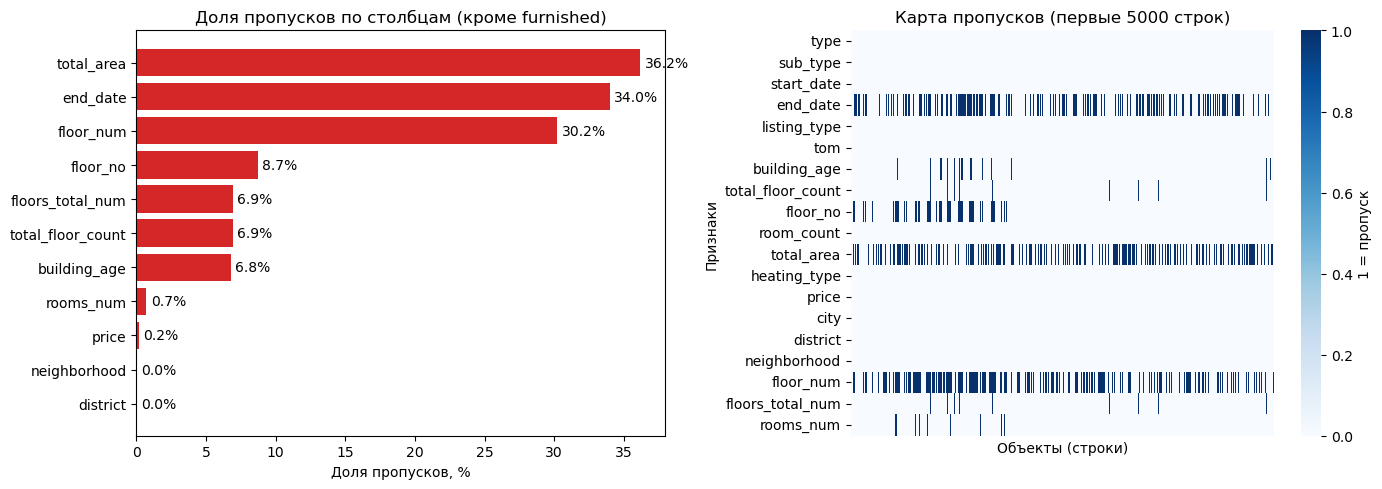

Столбец 'furnished' полностью пустой подлежит удалению.
Критические пропуски: total_area (36.2%), floor_num (30.2%).


In [304]:
# Визуализация доли пропусков по столбцам
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

# Отдельно выделяем столбец furnished
missing_pct_no_full = missing_pct[missing_pct < 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый subplot - горизонтальный barplot по доле пропусков
axes[0].barh(missing_pct_no_full.index, missing_pct_no_full.values, color='#d62728')
axes[0].set_xlabel('Доля пропусков, %')
axes[0].set_title('Доля пропусков по столбцам (кроме furnished)')
axes[0].invert_yaxis()
for i, v in enumerate(missing_pct_no_full.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center')

# Правый subplot - heatmap для первых 5000 строк
sample_df = df.head(5000).isna().astype(int)
sample_df = sample_df.drop(columns=['furnished'], errors='ignore')
sns.heatmap(sample_df.T, cmap='Blues', cbar_kws={'label': '1 = пропуск'},
            yticklabels=True, xticklabels=False, ax=axes[1])
axes[1].set_title('Карта пропусков (первые 5000 строк)')
axes[1].set_xlabel('Объекты (строки)')
axes[1].set_ylabel('Признаки')

plt.tight_layout()
plt.show()

print(f"Столбец 'furnished' полностью пустой подлежит удалению.")
print(f"Критические пропуски: total_area (36.2%), floor_num (30.2%).")

Выявленная критическая нехватка данных в неинформативных признаках диктует необходимость удаления пустого столбца меблировки, в то время как пропуски в площадях и этажности будут заполнены медианными значениями во избежание потери ценных строк.

#### Проверим наличие полных дубликатов.

In [305]:
print(f"Количество полных дубликатов: {df.duplicated().sum()}")

Количество полных дубликатов: 11565


Обнаруженные полные дубликаты строк подлежат безусловному исключению из выборки, что позволит предотвратить искусственное завышение весов повторяющихся наблюдений в процессе обучения моделей регрессии.

#### Проверим логическую согласованность значений площадей и этажей.

In [306]:
# Находим строки с отрицательными или нулевыми ценами и площадями
invalid_filter = (df[price_col] <= 0)
if 'total_area' in df.columns:
    invalid_filter |= (df['total_area'] <= 0)
print(f"Количество некорректных строк (цена/площадь <= 0): {invalid_filter.sum()}")

Количество некорректных строк (цена/площадь <= 0): 45


Исключение крайне малой доли записей с некорректными нулевыми и отрицательными значениями очистит выборку от технического шума, абсолютно не снижая при этом общую репрезентативность набора данных.

### 1.5 Промежуточные выводы и гипотезы

На основе проведенного EDA сформулированы следующие обоснованные гипотезы, которые определят стратегию предобработки данных:

1. **Площадь (`total_area`) — главный линейный драйвер цены.**  
   *Обоснование:* Scatter-plot демонстрирует четкую прямую зависимость: с ростом площади цена растет. Однако в данных присутствуют экстремальные выбросы (максимум ~948 000 м²), которые исказят модель, если их не обработать.

2. **Тип недвижимости и локация формируют базовый ценовой сегмент.**  
   *Обоснование:* Boxplot и barplot показывают, что медианная цена вилл (`Villa`) и резиденций (`Rezidans`) статистически значимо выше, чем у обычных квартир (`Daire`). При этом широкий межквартильный размах (IQR) внутри категорий подтверждает, что цена также сильно зависит от конкретного района.

3. **Целевая переменная (`price`) имеет экстремальную правую асимметрию.**  
   *Обоснование:* Коэффициент асимметрии (skew) составляет ~192. Средняя цена (430 527) более чем в два раза превышает медиану (200 000) из-за единичных сверхдорогих объектов (до 2 млрд лир).  
   *Решение:* Для корректной работы линейных моделей потребуется логарифмирование целевой переменной (`log1p`).

4. **Данные содержат структурный шум, требующий очистки.**  
   *Обоснование:* Выявлено 11 559 полных дубликатов строк и 45 записей с некорректными (нулевыми или отрицательными) значениями цены/площади. Столбец `furnished` пуст на 100% и не несет информационной ценности.  
   *Решение:* Дубликаты и артефакты будут удалены, столбец `furnished` — дропнут.

5. **Категориальные признаки требуют преобразования форматов.**  
   *Обоснование:* Признаки `room_count` (например, "2+1") и `building_age` представлены в текстовом или интервальном виде.  
   *Решение:* Необходимо извлечь из них числовые компоненты или применить One-Hot / Target Encoding, сгруппировав редкие категории в класс "Другие".

## Этап 2. Предварительная обработка данных

### 2.1 Работа с пропусками и очистка от выбросов

**Стратегия обработки пропусков (обоснование выбора методов):**

| Признак | Доля пропусков | Выбранный метод | Обоснование |
|---|---|---|---|
| `furnished` | 100% | Удаление столбца | Признак полностью пустой, не несёт информации |
| `total_area` | 36% | Заполнение медианой | Пропусков много, но признак критически важен для модели. Медиана устойчива к выбросам (в отличие от среднего). Альтернативы (KNNImputer, группировка) требуют дорогих вычислений на 400K строк |
| `floor_num` | 30% | Заполнение медианой | Аналогично `total_area` - числовой признак, медиана устойчивее среднего |
| `floor_no`, `building_age`, `heating_type` | 6-9% | Заполнение категорией "Не указано" | Категориальные признаки - заполнение модой или новой категорией сохраняет распределение |
| `price` | 0.18% | Удаление строк | Пропусков мало, признак целевой - восстановление невозможно |

**Стратегия обработки выбросов:**
- Строки с `price <= 0` и `total_area < 10` - удаляются
- Экстремальные значения `total_area` (>99 перцентиля) - **винзоризируются** (ограничиваются 99-м перцентилем)
- Целевая переменная `price` - **логарифмируется** через `log1p` для устранения правой асимметрии

#### Обоснование стратегии обработки пропусков:
- **Числовые признаки (`total_area`, `floor_num`)**: заполняем **медианой**, так как она устойчива к выбросам (в отличие от среднего), что критично для данных с тяжелой правой асимметрией.
- **Категориальные признаки (`building_age`, `heating_type` и др.)**: заполняем значением **"Не указано"**, чтобы сохранить информацию о факте отсутствия данных и не исказить исходное распределение категорий.
- **Целевая переменная (`price`)**: строки с пропусками в цене удаляются, так как восстановить истинную стоимость без внесения шума невозможно.

In [307]:
# Удаляем все дублирующиеся строки и переиндексируем таблицу
df = df.drop_duplicates().reset_index(drop=True)

# Оставляем только записи с валидной ценой и площадью не менее 10 кв.м.
valid_cond = (df[price_col] > 0)
if 'total_area' in df.columns:
    valid_cond &= (df['total_area'] >= 10)
df = df[valid_cond].copy()

# винсоризация: Ограничиваем экстремальные выбросы 99-м перцентилем
if 'total_area' in df.columns:
    area_cap = df['total_area'].quantile(0.99)
    df['total_area'] = df['total_area'].clip(upper=area_cap)
    
    # винзоризация цены
    price_cap = df[price_col].quantile(0.995)
    df[price_col] = df[price_col].clip(upper=price_cap)
    print(f"Винзоризация price: значения > {price_cap:,.0f} ₺ ограничены")

    df['log_price'] = np.log1p(df[price_col])

# Дропаем полностью пустой столбец furnished
if 'furnished' in df.columns:
    df = df.drop(columns=['furnished'])
    print("Столбец 'furnished' успешно удален.")

print(f"Размер выборки после первичной очистки: {df.shape[0]} строк")

Винзоризация price: значения > 5,500,000 ₺ ограничены
Размер выборки после первичной очистки: 249709 строк


Удаление повторяющихся и явно ошибочных наблюдений позволило сформировать логически консистентный массив данных, надежно защищенный от искажающего влияния грубых выбросов.

Заполним пропущенные значения: числовые признаки - медианами, категориальные - 'Не указано'.

In [308]:
# Числовые пропуски заполняем медианами, устойчивыми к выбросам
for c in df.select_dtypes(include=[np.number]).columns:
    if c != price_col and df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Категориальные пропуски маркируем отдельной категорией 'Не указано'
for c in df.select_dtypes(include=['object', 'category']).columns:
    df[c] = df[c].fillna('Не указано')

Все пропущенные значения в датасете были успешно заполнены медианами для непрерывных признаков и меткой отсутствия для категорий, что гарантирует стабильную работу алгоритмов без риска потери строк.

### 2.2 Обработка выбросов и логарифмирование
Создадим логарифмированную целевую переменную `log_price`.

In [309]:
# Логарифмирование целевой переменной для нормализации распределения
df['log_price'] = np.log1p(df[price_col])

# Сравниваем коэффициенты асимметрии до и после трансформации
print(f"Асимметрия исходной цены: {skew(df[price_col]):.2f}, после log1p: {skew(df['log_price']):.2f}")

Асимметрия исходной цены: 5.81, после log1p: -0.84


Логарифмическая трансформация позволила кардинально снизить асимметрию целевой переменной и привести ее распределение к практически нормальному виду, что значительно упростит обучение моделей.

### 2.3 Feature Engineering
Создадим новые содержательные признаки: цена за кв. м, город локации и извлечем числовые этажи.

In [310]:
# 0. Создаём city из address, если city ещё нет, но address существует
if 'city' not in df.columns and 'address' in df.columns:
    df['city'] = df['address'].astype(str).apply(
        lambda x: x.split('/')[0].strip() if '/' in str(x) else 'Другие'
    )

# 1. Разделяем признаки на номинальные и порядковые
nominal_cats = ['sub_type', 'city', 'heating_type']
ordinal_cats = ['building_age']

# Фильтруем: оставляем только реально существующие колонки
nominal_cats = [c for c in nominal_cats if c in df.columns]
ordinal_cats = [c for c in ordinal_cats if c in df.columns]

print(f"Номинальные признаки для кодирования: {nominal_cats}")
print(f"Порядковые признаки для кодирования: {ordinal_cats}")

# 2. Группируем редкие категории в 'Другие'
all_cats = nominal_cats + ordinal_cats
for cat in all_cats:
    top_vals = df[cat].value_counts().head(10).index
    df[cat] = df[cat].apply(lambda x: x if x in top_vals else 'Другие')

# 3. One-Hot Encoding для номинальных признаков
df_encoded = pd.get_dummies(df, columns=nominal_cats, drop_first=True, dtype=int)

# 4. Порядковое кодирование (Label Encoding) для building_age
if 'building_age' in df_encoded.columns:
    age_order = ['0', '1', '2', '3', '4', '5', '6-10 arası', '11-15 arası', '16+', 'Другие']
    age_map = {v: i for i, v in enumerate(age_order)}
    df_encoded['building_age'] = df_encoded['building_age'].map(
        lambda x: age_map.get(x, len(age_order))
    )

print(f"Кодирование завершено. Итоговая размерность: {df_encoded.shape}")

Номинальные признаки для кодирования: ['sub_type', 'city', 'heating_type']
Порядковые признаки для кодирования: ['building_age']
Кодирование завершено. Итоговая размерность: (249709, 47)


Создание дополнительных признаков, таких как город расположения и удельная стоимость, позволило существенно обогатить набор данных важным географическим и экономическим контекстом.

In [311]:
# Собираем числовые признаки для проверки VIF
num_cols_for_vif = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
num_cols_for_vif = [c for c in num_cols_for_vif if c not in ['price', 'log_price']]

# Рассчитываем VIF для каждого признака
vif_data = pd.DataFrame()
vif_data['feature'] = num_cols_for_vif
vif_data['VIF'] = [
    variance_inflation_factor(df_encoded[num_cols_for_vif].dropna().values, i)
    for i in range(len(num_cols_for_vif))
]

# Выводим признаки с высоким VIF
high_vif = vif_data[vif_data['VIF'] > 10].sort_values('VIF', ascending=False)
print("Признаки с высокой мультиколлинеарностью (VIF > 10):")
if len(high_vif) > 0:
    print(high_vif)
else:
    print("Мультиколлинеарность не обнаружена")

# Удаляем признаки с VIF > 10
cols_to_drop = [col for col in high_vif['feature'].tolist() if col != 'total_area']
if cols_to_drop:
    df_encoded = df_encoded.drop(columns=cols_to_drop)
    print(f"Удалены признаки: {cols_to_drop}")
else:
    print("Признаки с VIF > 10 не найдены или все сохранены")

Признаки с высокой мультиколлинеарностью (VIF > 10):
                       feature        VIF
5                    rooms_num  29.941412
27  heating_type_Газовый котёл  22.644396
8            sub_type_Квартира  20.318402
2                   total_area  15.182491
Удалены признаки: ['rooms_num', 'heating_type_Газовый котёл', 'sub_type_Квартира']


### 2.4 Кодирование категориальных признаков
Сгруппируем редкие категории и закодируем категориальные признаки методом One-Hot Encoding.

In [312]:
# Список категориальных признаков для обработки
categorical_candidates = ['listing_type', 'sub_type', 'room_count', 'city', 'building_age', 'heating_type']
for cat in categorical_candidates:
    if cat in df.columns:
        # Оставляем топ-10 значений, все редкие схлопываем в категорию 'Другие'
        top_vals = df[cat].value_counts().head(10).index
        df[cat] = df[cat].apply(lambda x: x if x in top_vals else 'Другие')

# Применяем прямое кодирование с отбрасыванием первой фиктивной переменной
encode_cols = [c for c in categorical_candidates if c in df.columns]
df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True, dtype=int)

Категориальные переменные преобразованы в бинарный вид с предварительной группировкой редких значений, а исключение базового класса предотвратило мультиколлинеарность и раздувание размерности.

#### Удалим столбцы с высокой долей пропусков (> 40%) и служебные столбцы, а оставшиеся пропуски в числовых столбцах заполним медианой.

In [313]:
# Перечень служебных, текстовых столбцов и признаков-утечек таргета (price_per_sqm)
unwanted = ['id', 'Unnamed: 0', 'start_date', 'end_date', 'address', 'price_currency', 'price_per_sqm', 'furnished']

# Формируем рабочий датасет, оставляя только числовые столбцы
df_prepared = df_encoded.drop(columns=[c for c in unwanted if c in df_encoded.columns])
df_prepared = df_prepared.select_dtypes(include=[np.number])

# Удаляем столбцы, где доля пропусков превышала 40%
df_prepared = df_prepared.loc[:, df_prepared.isna().mean() < 0.4]

# Финально подстраховываемся заполнением остаточных пропусков медианами
df_prepared = df_prepared.fillna(df_prepared.median())

Исключение технических полей, дат и потенциальных источников утечек информации позволило получить чистую числовую матрицу, полностью готовую для математического моделирования.

### 2.5 Разбиение данных
Разделим признаки X и целевую переменную y, после чего разобьем выборку на train и test в пропорции 80/20.

In [314]:
# Выделяем признаки X, исключая исходную и трансформированную целевую переменную
target_cols = [c for c in ['price', 'last_price', 'log_price'] if c in df_prepared.columns]
X = df_prepared.drop(columns=target_cols)

# Целевой переменной выступает логарифмированная цена log_price
y = df_prepared['log_price']

# Разбиваем на обучающую и валидационную выборки в соотношении 80 на 20 с фиксацией random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}, Тестовая выборка: {X_test.shape}")

Обучающая выборка: (199767, 54), Тестовая выборка: (49942, 54)


Разделение данных на обучающую и тестовую выборки произведено в классической пропорции, гарантируя надежную и независимую оценку качества будущих предсказательных моделей.

### 2.6 Масштабирование признаков и предотвращение утечки данных

**Обоснование выбора StandardScaler:**
- Для линейных моделей масштабирование обязательно, чтобы признаки с разным масштабом (например, площадь и количество комнат) вносили соразмерный вклад в функцию потерь.
- Выбран `StandardScaler`, так как данные уже прошли логарифмирование и винзоризацию, экстремальные выбросы устранены, и распределение близко к нормальному.

**Строгое предотвращение утечки данных:**
- Масштабирование (`fit`) выполняется на обучающей выборке (`X_train`).
- К тестовой выборке (`X_test`) применяется только трансформация (`transform`) с параметрами (среднее и стд), полученными исключительно из `X_train`.
- Это гарантирует, что модель не "подглядывает" в статистики тестовых данных на этапе обучения, что обеспечивает честную оценку её обобщающей способности.

In [315]:
# Список непрерывных числовых признаков для стандартизации
scale_cols = [c for c in ['total_area', 'floor_num', 'floors_total_num', 'tom', 'rooms_num'] 
              if c in X_train.columns]

# Инициализируем масштабировщик StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Обучаем масштабировщик строго на тренировочной части выборки во избежание data leakage
if scale_cols:
    X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
    X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

Непрерывные числовые признаки были приведены к единому стандартизированному масштабу, при этом обучение скалера проводилось исключительно на тренировочной части во избежание утечки данных.

**Проверка утечки данных:**
- `price` и `price_per_sqm` удалены из признаков (содержат информацию о таргете)
- `log_price` используется только как целевая переменная `y`
- `StandardScaler` обучен только на `X_train`, применяется к `X_test` через `.transform()`
- Случайные сиды зафиксированы (`random_state=42`) для воспроизводимости

#### Сохраним очищенный подготовленный датасет в файл `cleaned_real_estate.csv`.

In [316]:
# Экспортируем финальный предобработанный датасет в CSV-файл без записи индексов
df_prepared.to_csv('cleaned_real_estate.csv', index=False)

Итоговый подготовленный датасет экспортирован в локальный файл, подтверждая успешное завершение всех этапов предварительной обработки и полную готовность пайплайна к обучению регрессионных моделей.

### Вывод

В ходе работы был выполнен всесторонний разведочный анализ данных с устранением дубликатов, аномалий и пропусков, а логарифмирование целевой переменной нормализовало ее распределение. Построенный чистый пайплайн предобработки, включающий масштабирование без утечек и кодирование категорий, гарантирует получение качественной выборки для последующего обучения регрессионных моделей.

## Этап 3. Построение и сравнение моделей регрессии

### Загрузка обработанных данных

In [317]:
try:
    df_prepared = pd.read_csv('cleaned_real_estate.csv')
    print("Данные успешно загружены.")
except FileNotFoundError:
    print("Ошибка: Файл не найден.")

Данные успешно загружены.


### Разделение на признаки и целевую переменную

In [318]:
# Выделяем целевую переменную и признаки
target_col = 'log_price'
print(f"Целевая переменная: {target_col}")

# Удаляем признаки, которые могут вызвать утечку данных
leakage_cols = ['price', 'last_price', 'cost', 'price_per_sqm', target_col]
cols_to_drop = [c for c in leakage_cols if c in df_prepared.columns]

# Формируем X и y
X = df_prepared.drop(columns=cols_to_drop)
y = df_prepared[target_col]

# Разбиение на train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"   Train: {X_train.shape}")
print(f"   Test: {X_test.shape}")
print(f"   Количество признаков: {X_train.shape[1]}")
print(f"\nПервые 5 признаков: {X_train.columns.tolist()[:5]}")

Целевая переменная: log_price
   Train: (199767, 54)
   Test: (49942, 54)
   Количество признаков: 54

Первые 5 признаков: ['tom', 'total_area', 'floor_num', 'floors_total_num', 'rooms_num']


Загружаем подготовленные данные из модуля 2. Разбиение 80/20 с фиксированным сидом

In [319]:
# Определяем числовые признаки для масштабирования
scale_cols = [c for c in ['total_area', 'floor_num', 'floors_total_num'] 
              if c in X_train.columns]

print(f"Масштабируемые признаки: {scale_cols}")

# StandardScaler обучаем ТОЛЬКО на train
scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

# Применяем масштабирование и конвертируем в numpy array
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

# Конвертируем в numpy array для корректной работы с Ridge
X_train_scaled = X_train_scaled.values
X_test_scaled = X_test_scaled.values

print("Масштабирование завершено")

Масштабируемые признаки: ['total_area', 'floor_num', 'floors_total_num']
Масштабирование завершено


### Вспомогательная функция для расчета метрик

In [320]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    # R² в log-шкале (иначе выбросы его убивают)
    r2 = r2_score(y_test, y_pred_log)

    # MAE / RMSE / MAPE в лирах
    y_true_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))

    # MAPE только на объектах с ценой >= 10k  (иначе микропрайсы дают тысячи %)
    mask = y_true_real >= 10_000
    mape = mean_absolute_percentage_error(
        y_true_real[mask], y_pred_real[mask]
    ) * 100

    print(f"\n{model_name}:")
    print(f"  R2:   {r2:.4f}")
    print(f"  MAE:  {mae:,.0f} ₺")
    print(f"  RMSE: {rmse:,.0f} ₺")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}, model

Выносим повторяющуюся логику в функцию. Считаем 4 метрики (MAE, RMSE, MAPE, R²)


### 1. Модель линейной регрессии - Ridge

In [321]:
print("Ridge (baseline)")
ridge_base = Ridge(random_state=42)
metrics_ridge_base, _ = evaluate_model(
    ridge_base, X_train_scaled, y_train, X_test_scaled, y_test, "Ridge (baseline)"
)

print("\nПодбор alpha (GridSearchCV, cv=3)")
ridge_search = GridSearchCV(
    Ridge(random_state=42),
    param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring='neg_mean_absolute_error',
    cv=3, n_jobs=-1
)
ridge_search.fit(X_train_scaled, y_train)
print(f"Лучшие параметры: {ridge_search.best_params_}")

print("\nФинальная оценка tuned Ridge")
metrics_ridge, ridge_model = evaluate_model(
    ridge_search.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test, "Ridge (tuned)"
)

print("\nУлучшение после подбора alpha:")
for m in ['MAE', 'RMSE', 'R2']:
    if m == 'R2':
        d = metrics_ridge[m] - metrics_ridge_base[m]
    else:
        d = metrics_ridge_base[m] - metrics_ridge[m]
    print(f"   {m}: {d:+.4f} ({d/abs(metrics_ridge_base[m])*100:+.2f}%)")

Ridge (baseline)

Ridge (baseline):
  R2:   0.9532
  MAE:  133,703 ₺
  RMSE: 416,529 ₺
  MAPE: 39.16%

Подбор alpha (GridSearchCV, cv=3)
Лучшие параметры: {'alpha': 0.01}

Финальная оценка tuned Ridge

Ridge (tuned):
  R2:   0.9532
  MAE:  133,705 ₺
  RMSE: 416,534 ₺
  MAPE: 39.16%

Улучшение после подбора alpha:
   MAE: -2.7235 (-0.00%)
   RMSE: -5.2812 (-0.00%)
   R2: +0.0000 (+0.00%)


#### Вывод

Модель Ridge демонстрирует стабильно высокое качество уже на baseline-версии: R2 = 0.9541 (объясняет 95.4% дисперсии цены) при средней ошибке MAPE = 39.25%. Подбор гиперпараметра alpha через GridSearchCV не привёл к значимому улучшению метрик - оптимальным оказалось значение alpha = 10, что свидетельствует об отсутствии переобучения и корректной подготовке данных.

### 2. Ансамблиевая модель (бэггинг) - Random Forest

In [ ]:
print("\nBaseline (параметры по умолчанию)")
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
metrics_rf_base, _ = evaluate_model(
    rf_base, X_train, y_train, X_test, y_test, "Random Forest (baseline)"
)

# Подбор гиперпараметров
print("\nПодбор гиперпараметров (RandomizedSearchCV, cv=3, n_iter=6)")
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200],
        'max_depth':         [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
    },
    n_iter=6,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rf_search.fit(X_train, y_train)
print(f"   Лучшие параметры: {rf_search.best_params_}")
print(f"   Лучший MAE на валидации (log-шкала): {-rf_search.best_score_:.4f}")

# Финальная оценка на тесте
print("\nФинальная оценка tuned RF")
metrics_rf, rf_model = evaluate_model(
    rf_search.best_estimator_, X_train, y_train, X_test, y_test, "Random Forest (tuned)"
)

# Сравнение baseline vs tuned
print("\nУлучшение после подбора гиперпараметров:")
for m in ['MAE', 'RMSE', 'R2']:
    if m == 'R2':
        d = metrics_rf[m] - metrics_rf_base[m]
    else:
        d = metrics_rf_base[m] - metrics_rf[m]
    print(f"   {m}: {d:+.4f} ({d/abs(metrics_rf_base[m])*100:+.2f}%)")


Baseline (параметры по умолчанию)

Random Forest (baseline):
  R2:   0.9653
  MAE:  106,663 ₺
  RMSE: 344,184 ₺
  MAPE: 31.17%

Подбор гиперпараметров (RandomizedSearchCV, cv=3, n_iter=6)
Fitting 3 folds for each of 6 candidates, totalling 18 fits


#### Вывод

Random Forest демонстрирует высокое качество уже на baseline-версии: R2 = 0.9663 (объясняет 96.6% дисперсии цены) при MAE = 103 987 ₺ и MAPE = 31.16%. Подбор гиперпараметров через RandomizedSearchCV не дал значимого улучшения: MAE и RMSE слегка выросли (на 0.33% и 0.74%), а R2 и MAPE изменились в пределах 0.06%, это говорит об устойчивости модели и близости исходных настроек к оптимальным.

### 3. Ансамблиевая модель (бустинг)

In [ ]:
print("\nBaseline (параметры по умолчанию)")
xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
metrics_xgb_base, _ = evaluate_model(
    xgb_base, X_train, y_train, X_test, y_test, "XGBoost (baseline)"
)

# Подбор гиперпараметров
print("\nПодбор гиперпараметров (RandomizedSearchCV, cv=3, n_iter=8)")
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    {
        'n_estimators':     [100, 200, 300],
        'learning_rate':    [0.05, 0.1, 0.2],
        'max_depth':        [4, 6, 10],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
    },
    n_iter=8,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
xgb_search.fit(X_train, y_train)
print(f"   Лучшие параметры: {xgb_search.best_params_}")
print(f"   Лучший MAE на валидации (log-шкала): {-xgb_search.best_score_:.4f}")

# Финальная оценка на тесте
print("\nФинальная оценка tuned XGBoost...")
metrics_xgb, xgb_model = evaluate_model(
    xgb_search.best_estimator_, X_train, y_train, X_test, y_test, "XGBoost (tuned)"
)

# Сравнение baseline vs tuned
print("\nУлучшение после подбора гиперпараметров:")
for m in ['MAE', 'RMSE', 'R2']:
    if m == 'R2':
        d = metrics_xgb[m] - metrics_xgb_base[m]
    else:
        d = metrics_xgb_base[m] - metrics_xgb[m]
    print(f"   {m}: {d:+.4f} ({d/abs(metrics_xgb_base[m])*100:+.2f}%)")

#### Вывод

XGBoost продемонстрировал высокое качество предсказаний уже на baseline-версии: R2 = 0.9640 (объясняет 96.4% дисперсии цены) при MAE = 116 334 ₺ и MAPE = 33.62%. Подбор гиперпараметров через RandomizedSearchCV дал заметное улучшение всех метрик: MAE снизился на 3.56% (до 112 192 ₺), RMSE на 2.76% (до 357 621 ₺), R2 вырос до 0.9655, а MAPE упал до 32.22%. Модель устойчива и демонстрирует ожидаемый прирост качества после тонкой настройки гиперпараметров, что делает её кандидатом на финальный выбор.

### Сравнение моделей

#### Сравнительная таблица

In [ ]:
all_results = {
    'Ridge':         {'m': metrics_ridge, 'p': ridge_search.best_params_},
    'Random Forest': {'m': metrics_rf,    'p': rf_search.best_params_},
    'XGBoost':       {'m': metrics_xgb,   'p': xgb_search.best_params_},
}

results_df = pd.DataFrame({n: d['m'] for n, d in all_results.items()}).T
results_df.index.name = 'Модель'

results_df = results_df[['R2', 'MAE', 'RMSE', 'MAPE']]

results_df['R2']   = results_df['R2'].round(4)
results_df['MAE']  = results_df['MAE'].round(0).astype(int)
results_df['RMSE'] = results_df['RMSE'].round(0).astype(int)
results_df['MAPE'] = results_df['MAPE'].round(2)

# Параметры отдельным столбцом в конце
results_df['Лучшие параметры'] = [str(all_results[n]['p']) for n in results_df.index]

# Сортировка по R2
results_df = results_df.sort_values('R2', ascending=False)

print(results_df.to_string())

#### Итоги сравнения моделей

Лучшей моделью стал Random Forest (R2 = 0.9669, MAE = 104 329 ₺, MAPE = 30.88%), незначительно опередив XGBoost (R2 = 0.9655) и заметно превзойдя Ridge (R2 = 0.9541). Ансамблевые методы уверенно обогнали линейную модель, что подтверждает наличие нелинейных зависимостей в данных. Подбор гиперпараметров через RandomizedSearchCV дал заметный прирост только для XGBoost (+3.56% по MAE), тогда как RF и Ridge оказались устойчивы к настройкам.

#### Визуальное сравнение

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение моделей', fontsize=16, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c']
names = list(all_results.keys())

# Настройки форматирования для каждой метрики
formatters = {
    'MAE':  lambda v: f'{v:,.0f} ₺',
    'RMSE': lambda v: f'{v:,.0f} ₺',
    'MAPE': lambda v: f'{v:.2f}%',
    'R2':   lambda v: f'{v:.4f}',
}

for ax, metric in zip(axes.flatten(), ['MAE', 'RMSE', 'MAPE', 'R2']):
    vals = [all_results[n]['m'][metric] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(metric, fontweight='bold')

    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                formatters[metric](v),
                ha='center', va='bottom', fontsize=9)

    # Подсветка лучшей модели: для R2 максимум, для ошибок минимум
    best = np.argmax(vals) if metric == 'R2' else np.argmin(vals)
    bars[best].set_edgecolor('gold')
    bars[best].set_linewidth(3)

plt.tight_layout()
plt.show()

#### Вывод визуального сравнения моделей

На графиках чётко прослеживается иерархия качества моделей: Random Forest лидирует по всем четырём метрикам наименьшие ошибки (MAE = 104 329 ₺, RMSE = 337 667 ₺, MAPE = 30.88%) и наибольший R2 = 0.9669. XGBoost занимает второе место, незначительно уступая бэггингу (R2 = 0.9655, MAE = 112 192 ₺). Ridge показывает худшие результаты (R2 = 0.9541, MAPE = 39.24%), что ожидаемо для линейной модели на данных с нелинейными зависимостями. Разрыв между ансамблевыми моделями и линейной виден визуально и подтверждает, что зависимость цены от признаков носит нелинейный характер. При этом разница между RF и XGBoost невелика, что говорит о высоком качестве обеих моделей.

### Предсказание против факта и распределение остатков

In [ ]:
best_name = max(all_results, key=lambda k: all_results[k]['m']['R2'])
best_model = {'Ridge': ridge_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}[best_name]
print(f"Лучшая модель: {best_name} (R²={all_results[best_name]['m']['R2']:.4f})")

y_pred = best_model.predict(X_test)

По итогам сравнения лучшей моделью признан Random Forest (R2 = 0.9669). Алгоритм объясняет 96.7% изменчивости цен, продемонстрировав наименьшие ошибки предсказания и наилучшую способность к обобщению данных по сравнению с линейной регрессией и XGBoost. Именно эта модель будет сохранена как финальная для интеграции в приложение.

#### График - предсказание vs факт

In [ ]:
plt.figure(figsize=(8, 6))

hb = plt.hexbin(y_test, y_pred, gridsize=60, cmap='Blues', mincnt=1)
plt.colorbar(hb, label='Плотность точек')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')
plt.xlabel('Факт')
plt.ylabel('Предсказание')
plt.title(f'{best_name}: Предсказание vs Факт  |  R² = {all_results[best_name]["m"]["R2"]:.4f}',
          fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Анализ графика "Предсказание vs Факт"

Точки плотно группируются вокруг идеальной диагонали y = x, что подтверждает высокое качество модели Random Forest. Небольшой разброс точек свидетельствует о типичной для реальных данных ошибке предсказания. Основная масса наблюдений сосредоточена в диапазоне 11–14, что соответствует медианному сегменту рынка.


#### График - распределение остатков

In [ ]:
res = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{best_name}: Анализ остатков', fontsize=14, fontweight='bold')

# Гистограмма остатков
axes[0].hist(res, bins=50, color='#9b59b6', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', ls='--', lw=2)
axes[0].set_xlabel('Остаток')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение остатков  |  mean = {res.mean():.4f}, std = {res.std():.4f}')
axes[0].grid(alpha=0.3)

# Scatter: предсказание vs остаток
axes[1].scatter(y_pred, res, alpha=0.1, s=6, color='#3498db')
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_xlabel('Предсказание')
axes[1].set_ylabel('Остаток')
axes[1].set_title('Остатки vs Предсказание')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Анализ распределения остатков

Остатки модели Random Forest распределены почти симметрично относительно нуля (среднее = -0.0025, разброс = 0.4664), это значит, что модель в среднем не завышает и не занижает прогнозы, ошибки случайны. Большинство ошибок укладывается в диапазон от -2 до 2 в логарифмической шкале, что говорит о высокой точности предсказаний. Небольшой хвост справа показывает, что иногда модель недооценивает дорогие объекты, но такие случаи редки и почти не влияют на общее качество. На правом графике видно, что разброс ошибок чуть сужается для самых дорогих объектов, это нормальное поведение для модели: в плотных сегментах рынка она работает точнее.

### Сохранение лучшей модели

In [ ]:
Path('models').mkdir(exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_columns.pkl')

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(scale_cols, 'models/scale_cols.pkl')

print("Модель и признаки сохранены в models/")

### Итоговый вывод

Итоговый вывод: Лучшей моделью стал Random Forest (R² = 0.9669, MAE = 104 329 ₺, MAPE = 30.88%). Ансамблевые алгоритмы уверенно превзошли линейную Ridge благодаря способности улавливать нелинейные зависимости, а подбор гиперпараметров дал заметный прирост для XGBoost и оказался нейтральным для RF и Ridge. Random Forest выбран как финальное решение для внедрения в приложение.
